In [ ]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter



In [ ]:
# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shwetabh123/mall-customers",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_3554/2187872556.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mall-customers' dataset.


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Display basic info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (200, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Encode categorical variables (Gender)
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})



In [ ]:
# Select features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nPreprocessed data shape:", X_scaled.shape)
print("\n\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

print('\nBefore Scaling:\n\n')
print(X.describe().round(2))
print('\nAfter Scaling:\n\n')
# Convert X_scaled to a DataFrame to use .describe()
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.describe().round(2))
print('\n\n Preprocessing done!')


Preprocessed data shape: (200, 3)


First 5 rows of scaled data:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]

Before Scaling:


          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97               26.26                   25.82
min     18.00               15.00                    1.00
25%     28.75               41.50                   34.75
50%     36.00               61.50                   50.00
75%     49.00               78.00                   73.00
max     70.00              137.00                   99.00

After Scaling:


          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    -0.00               -0.00                   -0.00
std  

 Elbow Method (Find Optimal K)


  K=1  =>  Inertia = 600.00
  K=2  =>  Inertia = 389.39
  K=3  =>  Inertia = 295.21
  K=4  =>  Inertia = 205.23
  K=5  =>  Inertia = 168.25
  K=6  =>  Inertia = 133.87
  K=7  =>  Inertia = 117.01
  K=8  =>  Inertia = 103.87
  K=9  =>  Inertia = 93.09
  K=10  =>  Inertia = 82.39


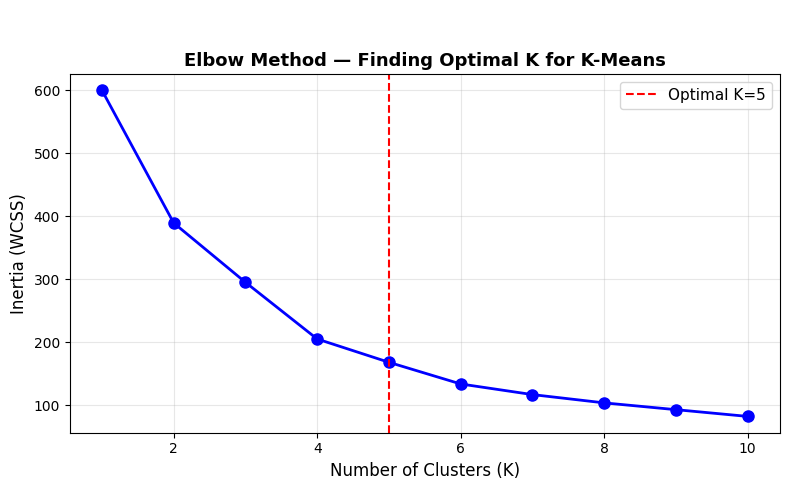

In [ ]:
print(' Elbow Method (Find Optimal K)\n\n')
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    print(f'  K={k}  =>  Inertia = {km.inertia_:0.2f}')

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal K=5')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('\n\nElbow Method — Finding Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print('Applying K-Means with K = 5\n')
print('=' * 60+'\n')

kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print('\nPrinting the kmeans_labels for understanding\n')
print(kmeans_labels)
print('\n\n')
# Add labels to original dataframe
df['KMeans_Cluster'] = kmeans_labels

print(f'K-Means fitted with K=5')
print(f'Cluster Centers (scaled):')
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(centers_df.round(3))


print('\nCluster Distribution:')
for i in range(5):
    count = (kmeans_labels == i).sum()
    print(f'  Cluster {i}: {count} customers  ({count/len(df)*100:.1f}%)')

print('\nCluster Summary (original scale):')
print(df.groupby('KMeans_Cluster')[features].mean().round(2))

Applying K-Means with K = 5



Printing the kmeans_labels for understanding

[1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 4 1 0 1 0 1 4 1 1 1 4 1 1 4 4 4 4 4 1 4 4 1 4 4 4 1 4 4 1 1 4 4 4 4
 4 1 4 4 1 4 4 1 4 4 1 4 4 1 1 4 4 1 4 4 1 1 4 1 4 1 1 4 4 1 4 1 4 4 4 4 4
 1 3 1 1 1 4 4 4 4 1 3 2 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 4 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2]



K-Means fitted with K=5
Cluster Centers (scaled):
     Age  Annual Income (k$)  Spending Score (1-100)
0  0.531              -1.291                  -1.236
1 -0.981              -0.743                   0.467
2 -0.429               0.975                   1.216
3  0.073               0.975                  -1.197
4  1.205              -0.236                  -0.052

Cluster Distribution:
  Cluster 0: 20 customers  (10.0%)
  Cluster 1: 54 customers  (27.0%)
  Cluster 2: 40 customers  (20.0%)
  Cluster 3: 39 c

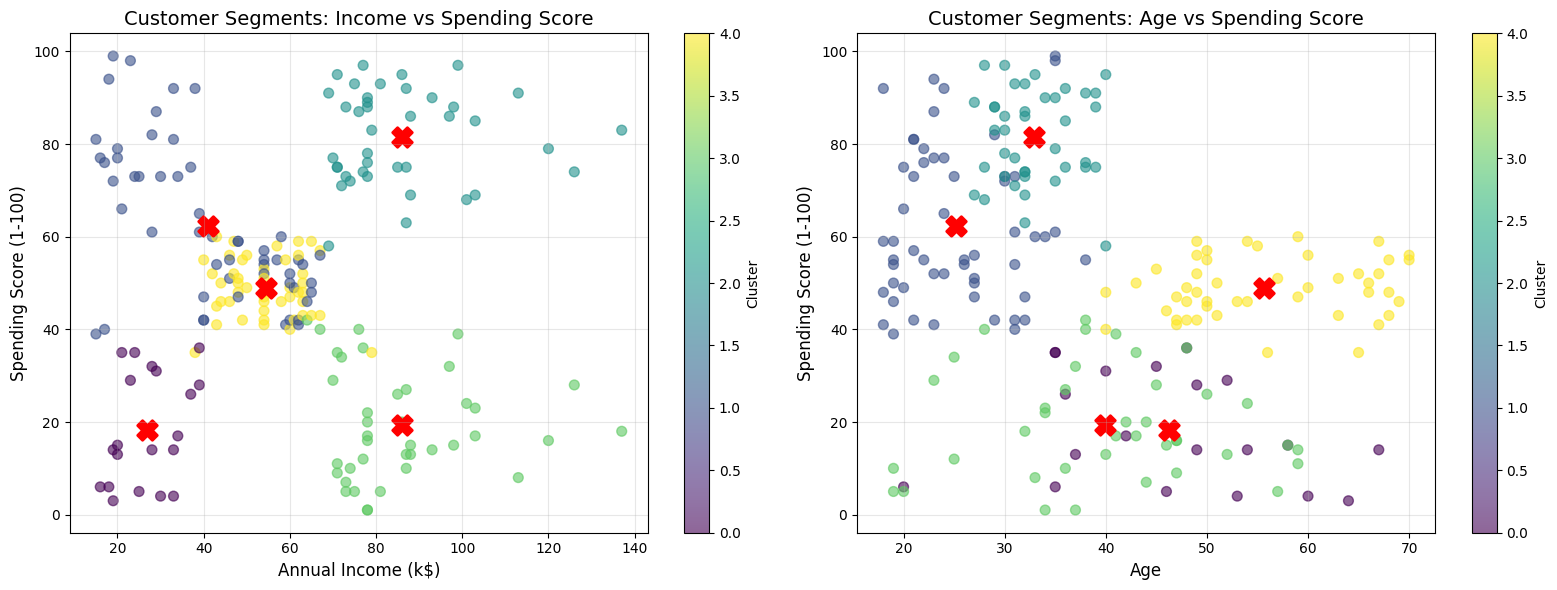

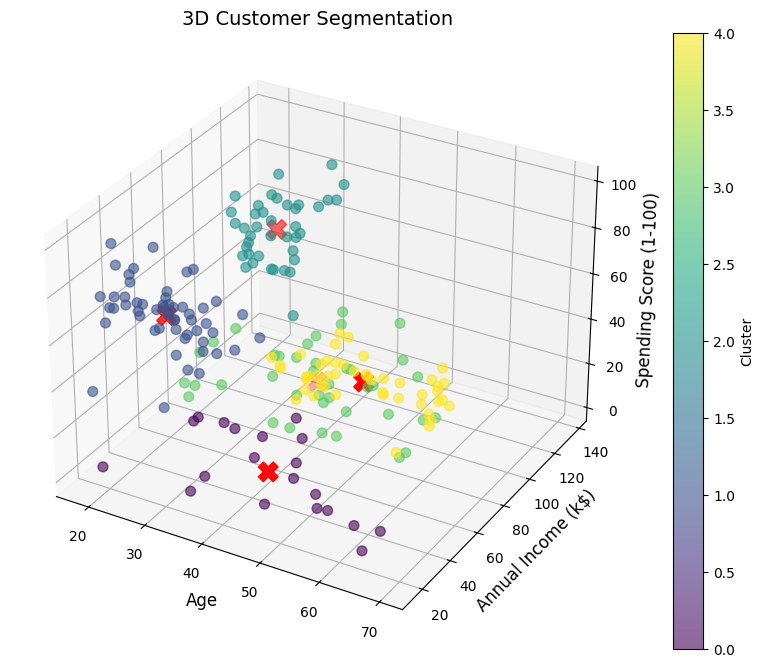

In [ ]:
# 2D Visualization (Annual Income vs Spending Score)
plt.figure(figsize=(16, 6))

# Plot 1: Income vs Spending Score
plt.subplot(1, 2, 1)
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.scatter(cluster_centers_df['Annual Income (k$)'],
           cluster_centers_df['Spending Score (1-100)'],
           c='red', marker='X', s=200, linewidth=2)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Segments: Income vs Spending Score', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Plot 2: Age vs Spending Score
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['Age'], df['Spending Score (1-100)'],
                     c=df['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.scatter(cluster_centers_df['Age'], cluster_centers_df['Spending Score (1-100)'],
           c='red', marker='X', s=200, linewidth=2)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Segments: Age vs Spending Score', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3D Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                    c=df['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.6)

ax.scatter(cluster_centers_df['Age'], cluster_centers_df['Annual Income (k$)'],
          cluster_centers_df['Spending Score (1-100)'], c='red', marker='X', s=200)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Annual Income (k$)', fontsize=12)
ax.set_zlabel('Spending Score (1-100)', fontsize=12)
ax.set_title('3D Customer Segmentation', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# Profile each cluster
cluster_profile = df.groupby('KMeans_Cluster').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'std', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'std', 'min', 'max'],
    'Genre': lambda x: (x == 1).mean()  # Proportion of Female
}).round(2)

# Rename columns for clarity
cluster_profile.columns = ['Age_Mean', 'Age_Std', 'Age_Min', 'Age_Max',
                           'Income_Mean', 'Income_Std', 'Income_Min', 'Income_Max',
                           'Spending_Mean', 'Spending_Std', 'Spending_Min', 'Spending_Max',
                           'Female_Proportion']

print("\n=== CLUSTER PROFILES ===")
print(cluster_profile)
print("\nCluster Sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Segment naming and insights
segment_names = {
    0: 'Standard Customers',
    1: 'High Spenders',
    2: 'Target Young High Income',
    3: 'Careful Low Spenders',
    4: 'Senior Budget Conscious'
}

df['Segment'] = df['KMeans_Cluster'].map(segment_names)

print("\n=== SEGMENT INSIGHTS ===")
for cluster in range(5):
    print(f"\n{'='*50}")
    print(f"Cluster {cluster}: {segment_names[cluster]}")
    print(f"{'='*50}")
    print(f"Size: {len(df[df['KMeans_Cluster'] == cluster])} customers ({len(df[df['KMeans_Cluster'] == cluster])/len(df)*100:.1f}%)")
    print(f"Average Age: {cluster_profile.loc[cluster, 'Age_Mean']:.1f} years")
    print(f"Average Annual Income: ${cluster_profile.loc[cluster, 'Income_Mean']:.0f}k")
    print(f"Average Spending Score: {cluster_profile.loc[cluster, 'Spending_Mean']:.1f}/100")
    print(f"Female Proportion: {cluster_profile.loc[cluster, 'Female_Proportion']*100:.1f}%")

    # Additional insights
    income_level = "High" if cluster_profile.loc[cluster, 'Income_Mean'] > 60 else "Medium" if cluster_profile.loc[cluster, 'Income_Mean'] > 40 else "Low"
    spending_level = "High" if cluster_profile.loc[cluster, 'Spending_Mean'] > 60 else "Medium" if cluster_profile.loc[cluster, 'Spending_Mean'] > 40 else "Low"

    print(f"\nCharacteristics: {income_level} Income, {spending_level} Spending")

    if cluster_profile.loc[cluster, 'Spending_Mean'] > 70:
        print("Action: VIP treatment, loyalty programs, premium offers")
    elif cluster_profile.loc[cluster, 'Spending_Mean'] < 30:
        print("Action: Discount campaigns, bundle offers to increase spending")
    elif cluster_profile.loc[cluster, 'Income_Mean'] > 70:
        print("Action: Premium products, luxury experiences")
    else:
        print("Action: Targeted marketing, cross-selling opportunities")


=== CLUSTER PROFILES ===
                Age_Mean  Age_Std  Age_Min  Age_Max  Income_Mean  Income_Std  \
KMeans_Cluster                                                                 
0                  46.25    11.58       20       67        26.75        7.31   
1                  25.19     5.51       18       38        41.09       16.82   
2                  32.88     3.86       27       40        86.10       16.34   
3                  39.87    10.94       19       59        86.10       16.73   
4                  55.64     8.91       40       70        54.38        8.82   

                Income_Min  Income_Max  Spending_Mean  Spending_Std  \
KMeans_Cluster                                                        
0                       16          39          18.35         11.94   
1                       15          67          62.24         16.60   
2                       69         137          81.53         10.00   
3                       64         137          19.36     